In [132]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
import asyncio
from langchain_experimental.utilities import PythonREPL

console = Console()

repl = PythonREPL()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# llm = ChatOpenAI(
#     model="stepfun/step-3.5-flash:free",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

llm = ChatOpenAI(
    model="gemini-2.5-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

In [133]:
class graph_state(BaseModel):
    question: str = Field(..., description = "Question to write code for")
    code: str = Field(..., description = "Code generated for the question")
    test_cases: List[dict] = Field(..., description = "Test cases to test the code on")
    results: List[dict]
    score: int = Field(..., description = "Final score after executing all test cases")
    iterations: int = Field(..., description = "No of tries done to execute correct code")

In [134]:
class coder_state(BaseModel):
    code: str = Field(..., description="Generated code")

In [135]:
def coder(state: graph_state) -> graph_state:
    question = state.question
    parser = PydanticOutputParser(pydantic_object=coder_state)
    response = llm.invoke(f"""You are a helpful code generator. You have to generate code in the provided format for the given question.
    Make sure to write code inside a function called solution and the function should return the final output.
    
    Question:

    {question}

    {parser.get_format_instructions()}

    """)
    parsed = parser.parse(response.content)
    return {
        'code': parsed.code,
    }

In [136]:
def evaluator(state: graph_state) -> graph_state:
    code = state.code
    test_cases = state.test_cases
    results = []
    passed = 0
    for t in test_cases:
        try:
            final_code = f"""
{code}
print(solution({repr(t['input'])}))
"""
            result = repl.run(final_code).strip()
            is_pass = result == t['expected']
            if is_pass:
                passed += 1
            results.append({
                'input': t['input'],
                'expected': t['expected'],
                'output': result,
                'is_pass': is_pass
            })
        except Exception as e:
            results.append({
                'input': t['input'],
                'expected': t['expected'],
                'error': str(e),
                'is_pass': False
            })
    score = passed / len(test_cases)
    return {
        'results': results,
        'score': score
    }


In [137]:
def fixer(state: graph_state) -> graph_state:
    question = state.question
    code = state.code
    results = state.results
    iterations = state.iterations
    parser = PydanticOutputParser(pydantic_object=coder_state)
    failed_cases = [t for t in results if not t['is_pass']]
    prompt = f"""
        You are a helpful assistant. You help in fixing the code provided for a question. You have been
        given test cases for which the code failed and the outputs or errors we got for those cases.
        Please analyze and fix the code. You have to generate code in the provided format.
        Make sure to write code inside a function called solution and the function should return the final output.
        
        Question:

        {question}

        Code:

        {code}

        Failed cases:

        {failed_cases}

        {parser.get_format_instructions()}

    """
    response = llm.invoke(prompt)
    parsed = parser.parse(response.content)
    return {
        'code': parsed.code,
        'iterations': iterations + 1
    }

In [138]:
def router(state: graph_state) -> str:
    score = state.score
    iterations = state.iterations
    if score < 1 and iterations < 2:
        return 'fixer'
    else:
        return 'end'

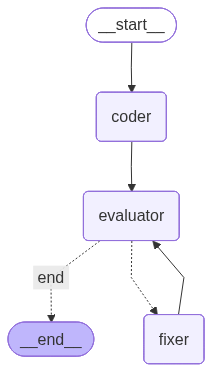

In [139]:
graph = StateGraph(graph_state)

graph.add_node('coder', coder)
graph.add_node('evaluator', evaluator)
graph.add_node('fixer', fixer)

graph.add_edge(START, 'coder')
graph.add_edge('coder', 'evaluator')
graph.add_edge('fixer', 'evaluator')
graph.add_conditional_edges('evaluator', router, {
    'fixer': 'fixer', 'end': END
})

coder_graph = graph.compile()

from IPython.display import Image, display
Image(coder_graph.get_graph().draw_mermaid_png())

In [140]:
tests = [
    {"input": 'abcabcbb', "expected": '3'},
    {"input": 'bbbbb', "expected": '1'},
    {"input": 'pwwkew', "expected": '3'},
]

graph_obj = graph_state(
    question = 'Given a string s, find the length of the longest substring without duplicate characters.',
    code = '',
    test_cases = tests,
    results = [],
    score = 0,
    iterations = 0
)

In [141]:
for chunk in coder_graph.stream(
    graph_obj,
    stream_mode="updates"
):
    print(chunk)

{
    'coder': {
        'code': 'def solution(s: str) -> int:\n    """\n    Given a string s, find the length of the longest 
substring without duplicate characters.\n\n    Args:\n        s: The input string.\n\n    Returns:\n        The 
length of the longest substring without duplicate characters.\n    """\n    left = 0\n    max_length = 0\n    
char_set = set()\n\n    for right in range(len(s)):\n        # If the current character s[right] is already in our 
set,\n        # it means we have a duplicate. We need to shrink the window\n        # from the left until the 
duplicate character is removed from the set.\n        while s[right] in char_set:\n            
char_set.remove(s[left])\n            left += 1\n        \n        # Add the current character to the set as it\'s 
now unique in the window.\n        char_set.add(s[right])\n        \n        # Update the maximum length found so 
far.\n        # The current window length is (right - left + 1).\n        max_length = max(max_length, right - left
+ 1)\n    \n    return max_length'
    }
}

{
    'evaluator': {
        'results': [
            {'input': 'abcabcbb', 'expected': '3', 'output': '3', 'is_pass': True},
            {'input': 'bbbbb', 'expected': '1', 'output': '1', 'is_pass': True},
            {'input': 'pwwkew', 'expected': '3', 'output': '3', 'is_pass': True}
        ],
        'score': 1.0
    }
}